# CAS Exam 5: Development Estimators & Pipeline in chainladder

Dataset used:
- `.../chainladder-python/chainladder/utils/data/friedland_us_industry_auto.csv`

**Learning goals:**
- Understand every parameter of `cl.Development`: `average`, `n_periods`, `drop_high`, `drop_low`, `drop_above`, `drop_valuation`
- Build hybrid (per-period) LDF selections using parameter lists
- Use `cl.DevelopmentConstant` to impose externally-selected patterns
- Fit `cl.ClarkLDF` (loglogistic / weibull) and compare to period-by-period averaging
- Apply `cl.TailCurve`, `cl.TailConstant`, and `cl.TailBondy`; compare implied tail factors
- Chain any estimators into a `cl.Pipeline` with the `step__param` naming convention
- Run `cl.GridSearch` over a parameter grid and interpret the full reserve range

## Formula Sheet Reference

### Development Averaging Methods

| Method | Formula | Use when |
|--------|---------|----------|
| **Volume-weighted** | $\frac{\sum C_{w,d+1}}{\sum C_{w,d}}$ | Default; downweights low-exposure years automatically |
| **Simple (arithmetic)** | $\frac{1}{n}\sum f_{w,d}$ | All accident years equally informative. Average change. |
| **Regression** | OLS through origin (numerically = volume-weighted) | Framing development as a regression for Mack assumptions |
| **Medial** | Drop 1 high + 1 low; simple-average the rest | Robust to a single outlier AY; formula-sheet listed |
| **Geometric** | $\exp\!\left(\frac{1}{n}\sum \ln f_{w,d}\right)$ | Less sensitive to extreme-high factors; formula-sheet listed. Constant (compounded) growth rate |

### `n_periods` Parameter

Restricts averaging to the **n most recent accident years**. Smaller values place more weight on recent experience. The trade-off: lower bias if patterns are trending, but higher variance from fewer data points.

### Tail Estimators

| Estimator | Method | Key parameters |
|-----------|--------|----------------|
| `TailCurve(curve='exponential')` | Fit $f_d = e^{-\theta d}$ to last few LDFs; extrapolate | `fit_period`, `extrap_periods`, `attachment_age` |
| `TailCurve(curve='inverse_power')` | Fit $f_d = d^{-\theta}$; heavier tail | Same as exponential |
| `TailConstant(tail=f)` | Apply fixed factor beyond last observed age | `tail`, `decay`, `attachment_age` |
| `TailBondy` | $\text{tail} = f_{\text{last}}^b$, $b$ fitted from pattern | `earliest_age`, `attachment_age` |
| `TailClark` | Extrapolates Clark's parametric growth curve | `growth`, `attachment_age` |

### Clark's Parametric Method (`cl.ClarkLDF`)

Fits a growth curve $G(x; \theta, \omega)$ to cumulative % paid data simultaneously across all accident years using MLE:

- **Loglogistic**: $G(x) = \dfrac{x^\omega}{x^\omega + \theta^\omega}$
- **Weibull**: $G(x) = 1 - e^{-(x/\theta)^\omega}$

LDFs are derived analytically: $f_d = G(d{+}\text{step}) / G(d)$. The tail is $f_\infty = 1 / G(d_{\text{last}})$ — no separate tail step is needed.

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import chainladder as cl

pd.set_option('display.float_format', lambda x: f'{x:,.5f}')
pd.set_option('display.max_columns', 15)

In [2]:
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

DATA_PATH = (
    ROOT / 'chainladder-python' / 'chainladder' / 'utils' / 'data'
    / 'friedland_us_industry_auto.csv'
)
raw = pd.read_csv(DATA_PATH)

triangle = cl.Triangle(
    raw,
    origin='Accident Year',
    development='Calendar Year',
    columns=['Paid Claims'],
    cumulative=True,
)
paid_triangle = triangle['Paid Claims']
paid_triangle

,12,24,36,48,60,72,84,96,108,120
1998,"18,539,254","33,231,039","40,062,008","43,892,039","45,896,535","46,765,422","47,221,322","47,446,877","47,555,456","47,644,187"
1999,"20,410,193","36,090,684","43,259,402","47,159,241","49,208,532","50,162,043","50,625,757","50,878,808","51,000,534",
2000,"22,120,843","38,976,014","46,389,282","50,562,385","52,735,280","53,740,101","54,284,334","54,533,225",,
2001,"22,992,259","40,096,198","47,767,835","52,093,916","54,363,436","55,378,801","55,878,421",,,
2002,"24,092,782","41,795,313","49,903,803","54,352,884","56,754,376","57,807,215",,,,
2003,"24,084,451","41,399,612","49,070,332","53,584,201","55,930,654",,,,,
2004,"24,369,770","41,489,863","49,236,678","53,774,672",,,,,,
2005,"25,100,697","42,702,229","50,644,994",,,,,,,
2006,"25,608,776","43,606,497",,,,,,,,
2007,"27,229,969",,,,,,,,,


## 1. `cl.Development` — The Core Estimator

`cl.Development` is an sklearn-style transformer: `.fit()` computes the LDF pattern, `.transform()` fills
the future cells (extends the triangle), and `.fit_transform()` does both in one step.

**Full parameter reference:**

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `average` | str or list | `'volume'` | Averaging method for each period: `'volume'`, `'simple'`, `'regression'` |
| `n_periods` | int or list | `-1` | Accident years to include (`-1` = all); list = per-period |
| `drop_high` | bool or list | `None` | Drop the single highest link ratio per period |
| `drop_low` | bool or list | `None` | Drop the single lowest link ratio per period |
| `drop_above` | float or list | `np.inf` | Exclude any ratio numerically above this threshold |
| `drop_below` | float or list | `0.0` | Exclude any ratio numerically below this threshold |
| `drop_valuation` | str or list | `None` | Exclude a specific calendar-year diagonal |
| `drop` | list | `None` | Exclude specific (origin, development) pairs |
| `preserve` | int | `1` | Minimum number of values to preserve before exclusions apply |

After `.fit(triangle)`:
- `.ldf_` — Triangle of volume-weighted (or selected) link ratios
- `.cdf_` — Cumulative development factors (product of LDFs right-to-left)
- `.sigma_` — Standard deviation of LDFs (used by Mack)
- `.std_err_` — Standard error of LDFs (used by Mack)

### Averaging Methods — Side-by-Side Comparison

All five chain-ladder averages shown together. **Regression** equals volume-weighted numerically
(both fit a line through the origin, weighted by the prior-age value). The differences between
methods are most visible at early-age transitions where individual AY factors vary the most.

In [3]:
specs = {
    'volume (all)':     cl.Development(average='volume',     n_periods=-1),
    'simple (all)':     cl.Development(average='simple',     n_periods=-1),
    'regression (all)': cl.Development(average='regression', n_periods=-1),
    'volume (last 5)':  cl.Development(average='volume',     n_periods=5),
    'volume (last 3)':  cl.Development(average='volume',     n_periods=3),
}

ldf_table = pd.DataFrame(
    {name: m.fit(paid_triangle).ldf_.to_frame().iloc[0] for name, m in specs.items()}
).T
ldf_table.index.name = 'method'

lr_frame = paid_triangle.link_ratio.to_frame()
geo_avg = np.exp(np.log(lr_frame.clip(lower=1e-9)).mean())
geo_avg.name = 'geometric (all)'
ldf_table = pd.concat([ldf_table, geo_avg.to_frame().T])

ldf_table.style.format('{:.5f}').background_gradient(axis=0, cmap='Blues')

,12-24,24-36,36-48,48-60,60-72,72-84,84-96,96-108,108-120
volume (all),1.73350,1.19176,1.09128,1.04391,1.01890,1.00953,1.00478,1.00234,1.00187
simple (all),1.73632,1.19222,1.09137,1.04394,1.01892,1.00954,1.00479,1.00234,1.00187
regression (all),1.73093,1.19134,1.09121,1.04388,1.01889,1.00952,1.00478,1.00234,1.00187
volume (last 5),1.71182,1.18864,1.09077,1.04361,1.01890,1.00953,1.00478,1.00234,1.00187
volume (last 3),1.70218,1.18600,1.09109,1.04385,1.01875,1.00946,1.00478,1.00234,1.00187
geometric (all),1.73604,1.19220,1.09137,1.04394,1.01892,1.00954,1.00479,1.00234,1.00187


### `n_periods` — Emphasizing Recent History

When link ratios trend over time (e.g., declining 12–24 factors as claims settle faster),
restricting to recent accident years reduces the influence of years that no longer reflect
current operations. The chart below shows how the LDF at each transition changes as `n_periods`
is reduced from all years down to 3.

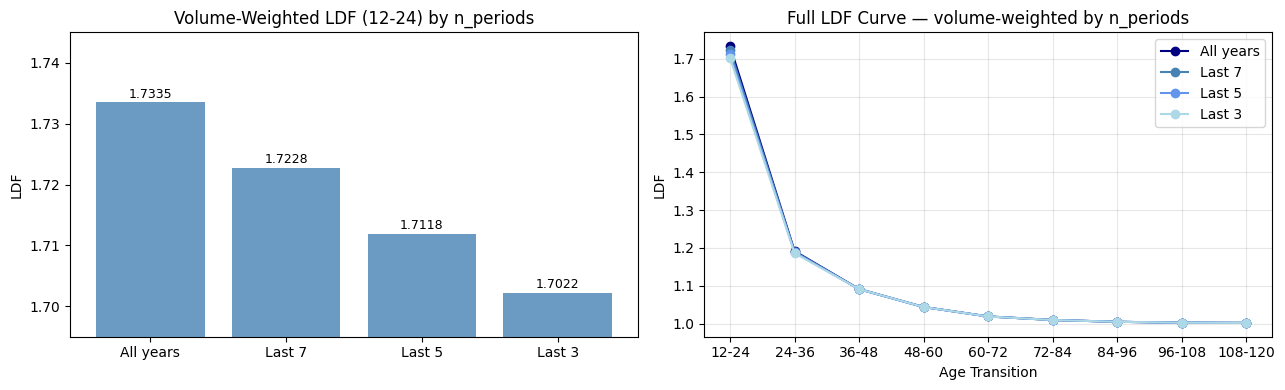

Total IBNR sensitivity to n_periods:


,total_ibnr
n_periods,
All years,"74,869,788.11824"
Last 7,"74,285,201.95867"
Last 5,"73,548,082.03946"
Last 3,"72,943,073.98590"


In [4]:
n_options = [-1, 7, 5, 3]
labels    = ['All years', 'Last 7', 'Last 5', 'Last 3']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left panel: 12-24 LDF by n_periods choice
first_trans = '12-24'
ldfs_first = [
    cl.Development(average='volume', n_periods=n).fit(paid_triangle).ldf_.to_frame().iloc[0][first_trans]
    for n in n_options
]
bars = axes[0].bar(labels, ldfs_first, color='steelblue', alpha=0.8)
axes[0].set_title(f'Volume-Weighted LDF ({first_trans}) by n_periods')
axes[0].set_ylabel('LDF')
for bar, v in zip(bars, ldfs_first):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 0.0003, f'{v:.4f}',
                 ha='center', va='bottom', fontsize=9)
axes[0].set_ylim(1.695, 1.745)

# Right panel: full LDF curve across all transitions
colors = ['navy', 'steelblue', 'cornflowerblue', 'lightblue']
for n, label, color in zip(n_options, labels, colors):
    ldfs = cl.Development(average='volume', n_periods=n).fit(paid_triangle).ldf_.to_frame().iloc[0]
    axes[1].plot(ldfs.index, ldfs.values, marker='o', label=label, color=color)
axes[1].set_title('Full LDF Curve — volume-weighted by n_periods')
axes[1].set_xlabel('Age Transition')
axes[1].set_ylabel('LDF')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary: total IBNR change as n_periods varies
print('Total IBNR sensitivity to n_periods:')
ibnr_rows = []
for n, label in zip(n_options, labels):
    dev = cl.Development(average='volume', n_periods=n).fit_transform(paid_triangle)
    ibnr = float(cl.Chainladder().fit(dev).ibnr_.sum())
    ibnr_rows.append({'n_periods': label, 'total_ibnr': ibnr})
pd.DataFrame(ibnr_rows).set_index('n_periods')

### Per-Period Parameter Lists — Hybrid Selections

Both `average` and `n_periods` accept **lists** (one element per development period transition).
This is the correct way to implement exam-style hybrid selections such as:
"use recent 3 years for 12–24 and 24–36; use all years for ages 36+".

The length of the list must equal the number of transitions in the triangle (`shape[-1] - 1`).

In [23]:
n_trans = paid_triangle.shape[-1] - 1   # number of age-to-age transitions
print(f'Triangle has {n_trans} transitions: {list(paid_triangle.link_ratio.to_frame().columns)}')

# Hybrid selection: recent years for early ages, all years for late ages.
# Interpretation: 12-24 and 24-36 are trending → use last 3.
#                 36-48 and 48-60 are moderately stable → use last 5.
#                 60+ are stable → use all available.
n_periods_hybrid = [3, 3, 5, 5] + [-1] * (n_trans - 4)
average_hybrid   = ['volume'] * n_trans

dev_hybrid  = cl.Development(average=average_hybrid, n_periods=n_periods_hybrid)
dev_all     = cl.Development(average='volume', n_periods=-1)

ldf_hybrid  = dev_hybrid.fit(paid_triangle).ldf_.to_frame().iloc[0]
ldf_all_vol = dev_all.fit(paid_triangle).ldf_.to_frame().iloc[0]

print(f'n_periods list: {n_periods_hybrid}')
pd.DataFrame({
    'hybrid [3,3,5,5,all,...]':  ldf_hybrid,
    'volume (all years)':         ldf_all_vol,
    'difference (hybrid − all)':  ldf_hybrid - ldf_all_vol,
})

Triangle has 9 transitions: ['12-24', '24-36', '36-48', '48-60', '60-72', '72-84', '84-96', '96-108', '108-120']
n_periods list: [3, 3, 5, 5, -1, -1, -1, -1, -1]


,"hybrid [3,3,5,5,all,...]",volume (all years),difference (hybrid − all)
12-24,1.70218,1.73350,-0.03132
24-36,1.18600,1.19176,-0.00576
36-48,1.09077,1.09128,-0.00051
48-60,1.04361,1.04391,-0.00030
60-72,1.01890,1.01890,0.00000
72-84,1.00953,1.00953,0.00000
84-96,1.00478,1.00478,0.00000
96-108,1.00234,1.00234,0.00000
108-120,1.00187,1.00187,0.00000


### Outlier Exclusion: `drop_high`, `drop_low`, `drop_above`, `drop_below`

Two complementary mechanisms for excluding outlier link ratios:

- **`drop_high=True` / `drop_low=True`** — drop the single largest / smallest ratio *per development period*. Works like a trimmed mean and is most useful with `average='simple'`.
- **`drop_above=f` / `drop_below=f`** — exclude any ratio numerically above/below a fixed threshold, across all periods. Useful when you know a factor above some value is data error or anomaly.

Both can also be passed as lists (one element per transition) for per-period control.
The `preserve` parameter (default 1) ensures at least that many values survive exclusion.

In [6]:
# Compare simple average with and without outlier exclusion
dev_simple     = cl.Development(average='simple', n_periods=-1)
dev_drop_hi_lo = cl.Development(average='simple', n_periods=-1, drop_high=True, drop_low=True)
dev_drop_above = cl.Development(average='simple', n_periods=-1, drop_above=2.0)

ldf_simple     = dev_simple.fit(paid_triangle).ldf_.to_frame().iloc[0]
ldf_drop_hi_lo = dev_drop_hi_lo.fit(paid_triangle).ldf_.to_frame().iloc[0]
ldf_drop_above = dev_drop_above.fit(paid_triangle).ldf_.to_frame().iloc[0]

# Number of AYs contributing to each period after exclusions (using volume average as reference)
n_contrib_simple = paid_triangle.link_ratio.to_frame().notna().sum()
print('Link ratios available per period (before exclusions):')
print(n_contrib_simple.to_frame().T.to_string())
print()

pd.DataFrame({
    'simple (all)':       ldf_simple,
    'drop hi+lo':         ldf_drop_hi_lo,
    'drop_above=2.0':     ldf_drop_above,
    'drop_hi_lo − base':  ldf_drop_hi_lo - ldf_simple,
})

Link ratios available per period (before exclusions):
   12-24  24-36  36-48  48-60  60-72  72-84  84-96  96-108  108-120
0      9      8      7      6      5      4      3       2        1



C:\Users\cphel\Documents\code\exam_5\chainladder-python\chainladder\development\base.py:588: UserWarning: Some exclusions have been ignored. At least 1 (use preserve = ...) link ratio(s) is required for development estimation.
  warnings.warn(warning)
C:\Users\cphel\Documents\code\exam_5\chainladder-python\chainladder\development\base.py:233: UserWarning: Some exclusions have been ignored. At least 1 (use preserve = ...) link ratio(s) is required for development estimation.
  warnings.warn(warning)


,simple (all),drop hi+lo,drop_above=2.0,drop_hi_lo − base
12-24,1.73632,1.73331,1.73632,-0.00301
24-36,1.19222,1.19115,1.19222,-0.00107
36-48,1.09137,1.09097,1.09137,-0.00040
48-60,1.04394,1.04375,1.04394,-0.00019
60-72,1.01892,1.01889,1.01892,-0.00003
72-84,1.00954,1.00950,1.00954,-0.00004
84-96,1.00479,1.00478,1.00479,-0.00001
96-108,1.00234,1.00234,1.00234,0.00000
108-120,1.00187,1.00187,1.00187,0.00000


### Calendar-Year Exclusion: `drop_valuation`

`drop_valuation` removes an entire calendar-year diagonal from the link ratio calculation.
This is used when a known event (catastrophe, mass tort, COVID, reserving change) distorted
one calendar year's development so that including it would bias the selected pattern.

From the L/S calendar-year diagnostic in `exam5_chainladdermethod.ipynb`, calendar year 2005
showed below-average development across multiple periods (`pct_L = 0.17`). We demonstrate
excluding that diagonal and comparing the resulting LDFs.

> **Format note** — the value passed to `drop_valuation` must match the triangle's valuation
> date format. For annual OYDY triangles, inspect `paid_triangle.valuation` to confirm.
> Common formats: `'2005-12'`, `pd.Period('2005', 'A-DEC')`, or integer `2005`.

In [7]:
# Inspect triangle valuation dates to understand the required format
print('Triangle valuation date (latest):', paid_triangle.valuation_date)
print()

dev_all = cl.Development(average='volume', n_periods=-1)
ldf_all = dev_all.fit(paid_triangle).ldf_.to_frame().iloc[0]

# Try multiple formats for drop_valuation (format varies by chainladder version)
ldf_ex = None
for fmt in ['2005-12', '2005', 2005]:
    try:
        dev_ex = cl.Development(average='volume', n_periods=-1, drop_valuation=fmt)
        ldf_ex = dev_ex.fit(paid_triangle).ldf_.to_frame().iloc[0]
        print(f'drop_valuation accepted format: {fmt!r}')
        break
    except Exception as e:
        print(f'Format {fmt!r} failed: {e}')

if ldf_ex is not None:
    pd.DataFrame({
        'volume (all diagonals)':     ldf_all,
        'volume (ex 2005 diagonal)':  ldf_ex,
        'difference':                 ldf_ex - ldf_all,
    })
else:
    print('drop_valuation demo requires inspection of triangle.valuation — see format note above.')
    ldf_all.to_frame().T

Triangle valuation date (latest): 2007-12-31 23:59:59.999999999

drop_valuation accepted format: '2005-12'


## 2. `cl.DevelopmentConstant` — Imposing Fixed Patterns

When you have externally-selected LDFs (from a pricing review, industry benchmark, or
actuarial judgment), `DevelopmentConstant` applies them directly without fitting from data.
This is also the correct tool for replicating a prior estimate's pattern or for sensitivity
testing with a fixed alternative pattern.

Parameters:
- `patterns`: dict mapping development age → LDF (or CDF)
- `style`: `'ldf'` (default) or `'cdf'`

In [8]:
# Externally-selected LDFs (from actuarial judgment or prior analysis)
ages = [12, 24, 36, 48, 60, 72, 84, 96, 108]
selected_ldfs = {
    12:  1.720,
    24:  1.190,
    36:  1.090,
    48:  1.040,
    60:  1.020,
    72:  1.010,
    84:  1.005,
    96:  1.002,
    108: 1.001,
}

dev_const = cl.DevelopmentConstant(patterns=selected_ldfs, style='ldf')
dev_const.fit(paid_triangle)

# Compare constant selection vs data-fitted volume-weighted
ldf_const = dev_const.ldf_.to_frame().iloc[0]
ldf_vol   = cl.Development(average='volume', n_periods=-1).fit(paid_triangle).ldf_.to_frame().iloc[0]

print('DevelopmentConstant — imposed LDFs vs data-fitted volume-weighted:')
comparison = pd.DataFrame({
    'imposed (DevelopmentConstant)': ldf_const,
    'data-fitted (volume, all)':      ldf_vol,
    'difference':                     ldf_const - ldf_vol,
})
comparison.style.format('{:.5f}')

DevelopmentConstant — imposed LDFs vs data-fitted volume-weighted:


,imposed (DevelopmentConstant),"data-fitted (volume, all)",difference
12-24,1.72000,1.73350,-0.01350
24-36,1.19000,1.19176,-0.00176
36-48,1.09000,1.09128,-0.00128
48-60,1.04000,1.04391,-0.00391
60-72,1.02000,1.01890,0.00110
72-84,1.01000,1.00953,0.00047
84-96,1.00500,1.00478,0.00022
96-108,1.00200,1.00234,-0.00034
108-120,1.00100,1.00187,-0.00087


In [9]:
# Project ultimate with the constant pattern
dev_const_tri = dev_const.transform(paid_triangle)
cl_const = cl.Chainladder().fit(dev_const_tri)
cl_vol   = cl.Chainladder().fit(cl.Development(average='volume', n_periods=-1).fit_transform(paid_triangle))

pd.DataFrame({
    'imposed_ultimate': cl_const.ultimate_.to_frame().iloc[:, 0].values,
    'fitted_ultimate':  cl_vol.ultimate_.to_frame().iloc[:, 0].values,
    'imposed_ibnr':     cl_const.ibnr_.to_frame().iloc[:, 0].values,
    'fitted_ibnr':      cl_vol.ibnr_.to_frame().iloc[:, 0].values,
}, index=paid_triangle.origin.year)

,imposed_ultimate,fitted_ultimate,imposed_ibnr,fitted_ibnr
origin,,,,
1998,"47,644,187.00000","47,644,187.00000",NaN,NaN
1999,"51,051,534.53400","51,095,692.97361","51,000.53400","95,158.97361"
2000,"54,696,933.74145","54,762,945.11524","163,708.74145","229,720.11524"
2001,"56,326,398.85994","56,382,145.64538","447,977.85994","503,724.64538"
2002,"58,853,362.58093","58,884,152.16999","1,046,147.58093","1,076,937.16999"
2003,"58,081,697.94092","58,049,658.97614","2,151,043.94092","2,119,004.97614"
2004,"58,076,510.71298","58,262,501.47933","4,301,838.71298","4,487,829.47933"
2005,"59,619,148.30264","59,880,496.19697","8,974,154.30264","9,235,502.19697"
2006,"61,086,804.19245","61,445,202.38622","17,480,307.19245","17,838,705.38622"


## 3. `cl.ClarkLDF` — Parametric Growth Curves

Instead of averaging period-by-period link ratios, `ClarkLDF` fits a smooth parametric
growth curve $G(x)$ to the cumulative % paid at every observed (origin, development age) cell
simultaneously, using maximum likelihood estimation.

**Advantages over period-by-period averaging:**
- Produces a smooth, monotone LDF pattern — no non-monotone behavior possible
- Extrapolates naturally into the tail from the fitted curve
- Statistically efficient: uses all cells, not just the lower-left corner
- Provides residuals for model diagnostics

**Limitations:**
- The chosen curve shape may not match the true development pattern
- Less transparent than a simple table of averages
- Requires non-zero values in all cells (sparse triangles can be problematic)

After `.fit(triangle)`:
- `.ldf_` — development factors derived from $G(d{+}\text{step})/G(d)$
- `.cdf_` — cumulative factors to ultimate ($1/G(d_{\text{last}})$)
- `.elr_` — expected loss ratio (MLE estimate)
- `.G_` — growth function values at each development age

In [10]:
# Fit both growth curve families
clark_logo = cl.ClarkLDF(growth='loglogistic').fit(paid_triangle)
clark_wbl  = cl.ClarkLDF(growth='weibull').fit(paid_triangle)

# LDFs derived from the fitted parametric curve
ldf_logo = clark_logo.ldf_.to_frame().iloc[0]
ldf_wbl  = clark_wbl.ldf_.to_frame().iloc[0]
ldf_vol  = cl.Development(average='volume', n_periods=-1).fit(paid_triangle).ldf_.to_frame().iloc[0]

ldf_compare = pd.DataFrame({
    'ClarkLDF (loglogistic)': ldf_logo,
    'ClarkLDF (weibull)':     ldf_wbl,
    'Development (volume)':   ldf_vol,
})

print('LDF comparison — parametric vs period-by-period:')
ldf_compare.style.format('{:.5f}')

LDF comparison — parametric vs period-by-period:


,ClarkLDF (loglogistic),ClarkLDF (weibull),Development (volume)
12-24,1.78427,1.76187,1.73350
24-36,1.16861,1.18924,1.19176
36-48,1.07451,1.08041,1.09128
48-60,1.04193,1.04022,1.04391
60-72,1.02682,1.02180,1.01890
72-84,1.01858,1.01239,1.00953
84-96,1.01361,1.00728,1.00478
96-108,1.01038,1.00438,1.00234
108-120,1.00817,1.00268,1.00187


In [11]:
# CDF-to-ultimate and implied tail
cdf_logo = clark_logo.cdf_.to_frame().iloc[0]
cdf_wbl  = clark_wbl.cdf_.to_frame().iloc[0]

# Clark includes tail implicitly in cdf_ (extends to age infinity via fitted curve)
# The tail factor = cdf at last observed age / (product of all remaining LDFs)
# i.e., the portion of cdf beyond the last observed development age
print('CDF-to-ultimate comparison:')
pd.DataFrame({
    'ClarkLDF (loglogistic)': cdf_logo,
    'ClarkLDF (weibull)':     cdf_wbl,
}).style.format('{:.5f}')

CDF-to-ultimate comparison:


,ClarkLDF (loglogistic),ClarkLDF (weibull)
12-Ult,2.52095,2.47104
24-Ult,1.41288,1.40251
36-Ult,1.20902,1.17933
48-Ult,1.12519,1.09156
60-Ult,1.07990,1.04936
72-Ult,1.05170,1.02697
84-Ult,1.03251,1.01440
96-Ult,1.01864,1.00707
108-Ult,1.00817,1.00268


In [12]:
# Ultimate comparison: ClarkLDF vs traditional Development + Chainladder
dev_fitted = cl.Development(average='volume', n_periods=-1).fit_transform(paid_triangle)
cl_fitted  = cl.Chainladder().fit(dev_fitted)

cl_clark_logo = cl.Chainladder().fit(clark_logo.transform(paid_triangle))
cl_clark_wbl  = cl.Chainladder().fit(clark_wbl.transform(paid_triangle))

ay_years = paid_triangle.origin.year
pd.DataFrame({
    'Development (vol)':      cl_fitted.ultimate_.to_frame().iloc[:, 0].values,
    'ClarkLDF (loglogistic)': cl_clark_logo.ultimate_.to_frame().iloc[:, 0].values,
    'ClarkLDF (weibull)':     cl_clark_wbl.ultimate_.to_frame().iloc[:, 0].values,
}, index=ay_years)

,Development (vol),ClarkLDF (loglogistic),ClarkLDF (weibull)
origin,,,
1998,"47,644,187.00000","47,644,187.00000","47,644,187.00000"
1999,"51,095,692.97361","51,417,385.06237","51,137,160.23520"
2000,"54,762,945.11524","55,549,885.14277","54,918,578.30282"
2001,"56,382,145.64538","57,694,961.13717","56,682,862.13885"
2002,"58,884,152.16999","60,795,659.35952","59,366,242.76723"
2003,"58,049,658.97614","60,399,552.68907","58,691,203.53435"
2004,"58,262,501.47933","60,506,470.03551","58,698,512.16586"
2005,"59,880,496.19697","61,231,052.42155","59,727,345.24204"
2006,"61,445,202.38622","61,610,634.29935","61,158,399.77185"


## 4. Tail Estimators

After fitting development factors to the observed triangle, a **tail estimator** extends the
pattern beyond the oldest observed development age.

All tail estimators are transformers: they accept a development-fitted triangle and return
a triangle with the tail appended. They can be chained via `Pipeline` (see Section 5).

**Key parameter shared by all tails:**
- `attachment_age`: the development age at which the tail begins. If `None`, it attaches
  at the last observed age. You can attach earlier to override the last few noisy observed factors.

In [13]:
# Base: development-fitted triangle (input for all tail estimators below)
dev_model = cl.Development(average='volume', n_periods=-1)
dev_tri   = dev_model.fit_transform(paid_triangle)

# TailCurve: fits exponential or inverse-power curve to the last few LDFs and extrapolates
tail_exp  = cl.TailCurve(curve='exponential').fit(dev_tri)
tail_pow  = cl.TailCurve(curve='inverse_power').fit(dev_tri)

# TailConstant: applies a fixed multiplier beyond the last age
tail_c100 = cl.TailConstant(tail=1.000)  # no tail
tail_c101 = cl.TailConstant(tail=1.010)  # 1% tail (industry benchmark example)
tail_c105 = cl.TailConstant(tail=1.050)  # 5% tail (long-tail lines)

# TailBondy: tail = f_last ^ b where b is fitted from the LDF progression
tail_bondy = cl.TailBondy().fit(dev_tri)

print('Implied tail factors (beyond age 120):')
tail_results = {
    'TailCurve (exponential)':  float(tail_exp.tail_.iloc[0, 0]),
    'TailCurve (inverse_power)': float(tail_pow.tail_.iloc[0, 0]),
    'TailConstant (1.000)':     1.000,
    'TailConstant (1.010)':     1.010,
    'TailConstant (1.050)':     1.050,
    'TailBondy':                float(tail_bondy.tail_.iloc[0, 0]),
}
for name, factor in tail_results.items():
    print(f'  {name:<30}: {factor:.5f}')

Implied tail factors (beyond age 120):
  TailCurve (exponential)       : 1.00109
  TailCurve (inverse_power)     : 1.01209
  TailConstant (1.000)          : 1.00000
  TailConstant (1.010)          : 1.01000
  TailConstant (1.050)          : 1.05000
  TailBondy                     : 1.00187


In [14]:
# Tail sensitivity: how much does the total IBNR change with each tail choice?
cl_model = cl.Chainladder()

tail_sensitivity = []
for name, tail_estimator in [
    ('TailCurve (exponential)',   cl.TailCurve(curve='exponential')),
    ('TailCurve (inverse_power)', cl.TailCurve(curve='inverse_power')),
    ('TailConstant (1.000)',      cl.TailConstant(tail=1.000)),
    ('TailConstant (1.010)',      cl.TailConstant(tail=1.010)),
    ('TailConstant (1.050)',      cl.TailConstant(tail=1.050)),
    ('TailBondy',                 cl.TailBondy()),
]:
    tailed    = tail_estimator.fit_transform(dev_tri)
    fitted    = cl_model.fit(tailed)
    tail_factor = float(tail_estimator.tail_.iloc[0, 0])
    total_ibnr  = float(np.nansum(fitted.ibnr_.values))
    tail_sensitivity.append({'TailEstimator': name, 'TailFactor': tail_factor, 'TotalIBNR': total_ibnr})

sens_df = pd.DataFrame(tail_sensitivity).set_index('TailEstimator')
sens_df['IBNRvsNoTail'] = sens_df['TotalIBNR'] - sens_df.loc['TailConstant (1.000)', 'TotalIBNR']
sens_df.style.format({'TailFactor': '{:.5f}', 'TotalIBNR': '{:,.0f}', 'IBNRvsNoTail': '{:,.0f}'})

,TailFactor,TotalIBNR,IBNRvsNoTail
TailEstimator,,,
TailCurve (exponential),1.00109,"75,495,978","626,189"
TailCurve (inverse_power),1.01209,"81,796,954","6,927,166"
TailConstant (1.000),1.00000,"74,869,788",0
TailConstant (1.010),1.01000,"80,598,990","5,729,202"
TailConstant (1.050),1.05000,"103,515,796","28,646,008"
TailBondy,1.00187,"75,938,767","1,068,979"


In [15]:
# attachment_age: begin the curve fit from an earlier age to override noisy late observed factors.
# Useful when the last 1-2 development periods are sparse and produce erratic LDFs.

print('TailCurve — effect of attachment_age on tail factor:')
rows = []
for attach in [None, 96, 84, 72]:
    t = cl.TailCurve(curve='exponential', attachment_age=attach).fit(dev_tri)
    rows.append({'attachment_age': attach if attach else 'last observed', 'tail_factor': float(t.tail_.iloc[0, 0])})

pd.DataFrame(rows).set_index('attachment_age')

TailCurve — effect of attachment_age on tail factor:


,tail_factor
attachment_age,
last observed,1.00109
96,1.00109
84,1.00109
72,1.00109


## 5. `cl.Pipeline` — Chaining Estimators

`Pipeline` chains a sequence of estimators (transformers + a final estimator) into a single
sklearn-compatible object. The steps are named tuples: `(name, estimator)`.

**Why use Pipeline:**
- A single `.fit(triangle)` call runs the entire chain in sequence
- Hyperparameters are addressed as `step_name__param_name` — no intermediate variables needed
- Makes `GridSearch` trivial: one `param_grid` dict sweeps the entire chain

**Step naming convention:** each step's parameters are accessed as `stepname__param`, e.g.:
- `dev__average` → the `average` parameter of the step named `'dev'`
- `tail__curve` → the `curve` parameter of the step named `'tail'`

**Accessing results after `.fit()`:**
- `pipe.named_steps['stepname']` → the fitted estimator for that step
- `pipe.named_steps['model'].ibnr_` → IBNR Triangle from the final fitted model

> **Note** — `Pipeline` does **not** proxy actuarial attributes like `.ibnr_` directly.
> Always go through `named_steps` to access model outputs.

In [16]:
# Build a complete reserving pipeline: Development → TailCurve → Chainladder
pipe = cl.Pipeline([
    ('dev',   cl.Development(average='volume', n_periods=-1)),
    ('tail',  cl.TailCurve(curve='exponential')),
    ('model', cl.Chainladder()),
])
pipe.fit(paid_triangle)

# Access results via named_steps — Pipeline does NOT proxy .ibnr_ directly
fitted_dev   = pipe.named_steps['dev']
fitted_tail  = pipe.named_steps['tail']
fitted_model = pipe.named_steps['model']

print('Step: dev   →', fitted_dev)
print('Step: tail  →', fitted_tail)
print('Step: model →', fitted_model)
print()
print(f'Tail factor (TailCurve exponential): {float(fitted_tail.tail_.iloc[0, 0]):.5f}')
print(f'Total IBNR:                          {float(np.nansum(fitted_model.ibnr_.values)):,.0f}')

Step: dev   → Development()
Step: tail  → TailCurve()
Step: model → Chainladder()

Tail factor (TailCurve exponential): 1.00109
Total IBNR:                          75,495,978


In [17]:
# Accessing LDFs, CDFs, and ultimates from the pipeline
ldf_pipe = fitted_dev.ldf_.to_frame()
cdf_pipe = fitted_tail.cdf_.to_frame()   # CDF after tail is appended
ult_pipe  = fitted_model.ultimate_.to_frame()
ibnr_pipe = fitted_model.ibnr_.to_frame()

print('LDFs from pipeline dev step:')
print(ldf_pipe.to_string())
print()

# Full AY projection table
ay_years = paid_triangle.origin.year
pd.DataFrame({
    'Latest':   paid_triangle.latest_diagonal.to_frame(origin_as_datetime=False, keepdims=True).iloc[:, 0].values,
    'Ultimate': fitted_model.ultimate_.to_frame(origin_as_datetime=False, keepdims=True).iloc[:, 0].values,
    'IBNR':     fitted_model.ibnr_.to_frame(origin_as_datetime=False, keepdims=True).iloc[:, 0].values,
}, index=ay_years)

LDFs from pipeline dev step:
        12-24   24-36   36-48   48-60   60-72   72-84   84-96  96-108  108-120
(All) 1.73350 1.19176 1.09128 1.04391 1.01890 1.00953 1.00478 1.00234  1.00187



,Latest,Ultimate,IBNR
origin,,,
1998,1998,1998,1998
1999,1999,1999,1999
2000,2000,2000,2000
2001,2001,2001,2001
2002,2002,2002,2002
2003,2003,2003,2003
2004,2004,2004,2004
2005,2005,2005,2005
2006,2006,2006,2006


In [18]:
# set_params: swap a single parameter without rebuilding the pipeline
# This is the correct way to do one-off sensitivity checks with a pipeline.
# Note: set_params modifies in-place and returns self.

import copy

pipe_simple = copy.deepcopy(pipe)
pipe_simple.set_params(dev__average='simple', dev__n_periods=5, tail__curve='inverse_power')
pipe_simple.fit(paid_triangle)

ibnr_vol    = float(np.nansum(pipe.named_steps['model'].ibnr_.values))
ibnr_simple = float(np.nansum(pipe_simple.named_steps['model'].ibnr_.values))

print(f'Original pipeline  (volume / exp):  IBNR = {ibnr_vol:,.0f}')
print(f'Modified pipeline  (simple / pow):  IBNR = {ibnr_simple:,.0f}')
print(f'Difference:                                 {ibnr_simple - ibnr_vol:+,.0f}')

Original pipeline  (volume / exp):  IBNR = 75,495,978
Modified pipeline  (simple / pow):  IBNR = 80,559,487
Difference:                                 +5,063,509


## 6. `cl.GridSearch` — Systematic Sensitivity Analysis

`GridSearch` fits every combination in a `param_grid` and records the output of a `scoring`
function for each. The result is a DataFrame (`grid.results_`) with one row per combination.

**Key parameters:**
- `estimator`: the `Pipeline` (or any estimator) to sweep
- `param_grid`: dict of `{step__param: [values]}` — same naming as `set_params`
- `scoring`: callable `(fitted_estimator) -> float` — or a dict of multiple scorers

**Scoring function pattern:**
```python
# fitted_estimator is the fitted Pipeline after .fit(triangle)
# Access model results via named_steps:
scoring = lambda est: float(np.nansum(est.named_steps['model'].ibnr_.values))
```

**What the reserve range tells you:**
- Spread = model risk from averaging and tail assumptions alone
- If the spread is small relative to the selected reserve, assumptions are not a major driver
- If the spread is large, the selected assumption deserves explicit disclosure

In [24]:
import copy

# Fresh pipeline for GridSearch (GridSearch clones internally, but start clean)
pipe_gs = cl.Pipeline([
    ('dev',   cl.Development()),
    ('tail',  cl.TailCurve()),
    ('model', cl.Chainladder()),
])

param_grid = {
    'dev__average':   ['volume', 'simple', 'regression'],
    'dev__n_periods': [3, 5, -1],           # -1 = all available years
    'tail__curve':    ['exponential', 'inverse_power'],
}

# Scoring: total IBNR across all accident years.
# The lambda receives the FITTED PIPELINE — access results via named_steps.
def score_ibnr(est):
    return float(np.nansum(est.named_steps['model'].ibnr_.values))

grid = cl.GridSearch(
    pipe_gs,
    param_grid=param_grid,
    scoring=score_ibnr,
)
grid.fit(paid_triangle)

total_combos = len(grid.results_)
print(f'Total combinations fitted: {total_combos}  '
      f'({len(param_grid["dev__average"])} avg × '
      f'{len(param_grid["dev__n_periods"])} n_periods × '
      f'{len(param_grid["tail__curve"])} curves)')
grid.results_.rename(columns={'score': 'total_ibnr'}).head()

Total combinations fitted: 18  (3 avg × 3 n_periods × 2 curves)


,dev__average,dev__n_periods,tail__curve,total_ibnr
0,volume,3,exponential,"73,577,120.91192"
1,volume,3,inverse_power,"79,961,549.71106"
2,volume,5,exponential,"74,180,311.40924"
3,volume,5,inverse_power,"80,543,657.88059"
4,volume,-1,exponential,"75,495,977.59491"


In [25]:
# Rank all combinations from lowest to highest IBNR
results = (
    grid.results_
    .rename(columns={'score': 'total_ibnr'})
    .sort_values('total_ibnr')
    .reset_index(drop=True)
)

ibnr_min  = results['total_ibnr'].min()
ibnr_max  = results['total_ibnr'].max()
spread    = ibnr_max - ibnr_min

print(f'IBNR range across {len(results)} combinations:')
print(f'  Low  (rank  1): {ibnr_min:>12,.0f}')
print(f'  High (rank {len(results):2d}): {ibnr_max:>12,.0f}')
print(f'  Spread:         {spread:>12,.0f}  ({spread / ibnr_min:.1%} of low)')
print()

results.style.background_gradient(subset=['total_ibnr'], cmap='RdYlGn_r').format(
    {'total_ibnr': '{:,.0f}'}
)

IBNR range across 18 combinations:
  Low  (rank  1):   73,573,514
  High (rank 18):   81,977,626
  Spread:            8,404,112  (11.4% of low)



,dev__average,dev__n_periods,tail__curve,total_ibnr
0,regression,3,exponential,"73,573,514"
1,volume,3,exponential,"73,577,121"
2,simple,3,exponential,"73,580,407"
3,regression,5,exponential,"74,165,271"
4,volume,5,exponential,"74,180,311"
5,simple,5,exponential,"74,195,044"
6,regression,-1,exponential,"75,326,037"
7,volume,-1,exponential,"75,495,978"
8,simple,-1,exponential,"75,682,697"
9,regression,3,inverse_power,"79,957,297"


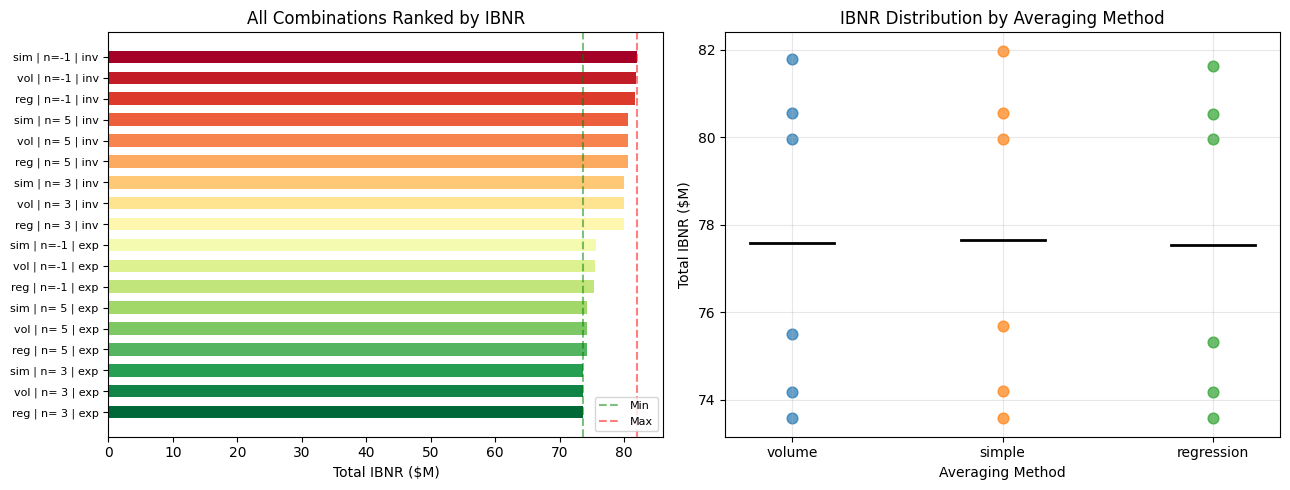


Mean IBNR by averaging method:


,min,mean,max
dev__average,,,
regression,"73,573,514","77,530,296","81,632,288"
simple,"73,580,407","77,660,090","81,977,626"
volume,"73,577,121","77,592,595","81,796,954"


In [21]:
# Visualize the reserve range as a horizontal dot plot (tornado-style)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: all combinations sorted by IBNR
ax = axes[0]
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(results)))
ax.barh(range(len(results)), results['total_ibnr'] / 1e6, color=colors, height=0.6)
ax.set_yticks(range(len(results)))
ax.set_yticklabels(
    [f"{r['dev__average'][:3]} | n={r['dev__n_periods']:>2} | {r['tail__curve'][:3]}"
     for _, r in results.iterrows()],
    fontsize=8,
)
ax.set_xlabel('Total IBNR ($M)')
ax.set_title('All Combinations Ranked by IBNR')
ax.axvline(ibnr_min / 1e6, color='green', linestyle='--', alpha=0.5, label='Min')
ax.axvline(ibnr_max / 1e6, color='red',   linestyle='--', alpha=0.5, label='Max')
ax.legend(fontsize=8)

# Right: box plot by averaging method
ax2 = axes[1]
for i, avg_method in enumerate(['volume', 'simple', 'regression']):
    subset = results[results['dev__average'] == avg_method]['total_ibnr'] / 1e6
    ax2.scatter([i] * len(subset), subset, alpha=0.7, s=60)
    ax2.plot([i - 0.2, i + 0.2], [subset.mean(), subset.mean()], 'k-', linewidth=2)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['volume', 'simple', 'regression'])
ax2.set_xlabel('Averaging Method')
ax2.set_ylabel('Total IBNR ($M)')
ax2.set_title('IBNR Distribution by Averaging Method')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary by averaging method
print('\nMean IBNR by averaging method:')
results.groupby('dev__average')['total_ibnr'].agg(['min', 'mean', 'max']).apply(
    lambda col: col.map('{:,.0f}'.format)
)

In [22]:
# Which parameters drive the most IBNR variation?
# Compare the within-group spread for each parameter.

print('IBNR range by parameter value (shows which parameters matter most):')
print()
for param in ['dev__average', 'dev__n_periods', 'tail__curve']:
    grouped = results.groupby(param)['total_ibnr'].agg(['min', 'max'])
    grouped['spread'] = grouped['max'] - grouped['min']
    grouped['pct_of_total_spread'] = grouped['spread'] / spread * 100
    grouped.columns = ['Min IBNR', 'Max IBNR', 'Within-Group Spread', '% of Total Spread']
    print(f'--- {param} ---')
    print(grouped.to_string())
    print()

IBNR range by parameter value (shows which parameters matter most):

--- dev__average ---
                     Min IBNR         Max IBNR  Within-Group Spread  % of Total Spread
dev__average                                                                          
regression   73,573,513.56967 81,632,288.35350      8,058,774.78383           95.89085
simple       73,580,406.92539 81,977,625.98027      8,397,219.05488           99.91798
volume       73,577,120.91192 81,796,953.78297      8,219,832.87105           97.80727

--- dev__n_periods ---
                       Min IBNR         Max IBNR  Within-Group Spread  % of Total Spread
dev__n_periods                                                                          
-1             75,326,036.95882 81,977,625.98027      6,651,589.02145           79.14684
 3             73,573,513.56967 79,965,276.72805      6,391,763.15839           76.05518
 5             74,165,270.76731 80,559,486.83541      6,394,216.06810           76.08437

--- t

## Summary

| Component | Key takeaway |
|-----------|-------------|
| `Development(average=...)` | Volume-weighted is the default; use simple/medial when you want equal AY weighting; regression = volume-weighted numerically |
| `Development(n_periods=n)` | Restricts to n most recent AYs — useful when patterns are trending but adds variance |
| Per-period lists | Pass `average=[...]` and `n_periods=[...]` to implement exam-style hybrid selections |
| `drop_high` / `drop_low` | Trim extreme AY factors per transition; most useful with simple average |
| `drop_above` / `drop_valuation` | Threshold-based or diagonal-based exclusions for known anomalies |
| `DevelopmentConstant` | Impose externally-selected patterns without fitting |
| `ClarkLDF` | Parametric curve fit (loglogistic / weibull); smoother and self-tailing |
| `TailCurve` | Data-driven tail; sensitive when late-age LDFs are sparse |
| `TailConstant` | Use when an external benchmark is available and defensible |
| `TailBondy` | Self-referencing; attaches at last observed LDF; no external input needed |
| `Pipeline` | Chains any estimators; use `step__param` notation; access results via `named_steps` |
| `GridSearch` | Sweeps all combinations; scoring receives the **fitted Pipeline**; results in `.results_` |

**Exam 5 pattern to remember:** LDF selection is a judgment call. The chain ladder method's output
is only as good as the selected development factors. Any exam question that asks "what happens to
the ultimate if you use recent-year factors instead of all-year factors?" is asking you to run a
sensitivity analysis — exactly what `GridSearch` does systematically.